# Loan Default Risk Predictor
### 3MTT Capstone Project

**Goal:** predict whether a loan applicant is likely to default, using a classification pipeline built in Python.

This notebook walks through the full process: exploring the data, cleaning and engineering features, training two models, and evaluating which one performs better and why.


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

%matplotlib inline
sns.set_style("whitegrid")

TARGET_COLUMN = "Default"
RANDOM_STATE = 42


In [2]:
# Swap this path to your real Kaggle dataset once downloaded, e.g. "data/loan_data.csv"
df = pd.read_csv("data/sample_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (2000, 10)


,age,income,employment_years,credit_score,loan_amount,debt_to_income,existing_loans,home_ownership,loan_purpose,Default
0,58,64934.28,2.5,581.0,9598.57,0.131,0,RENT,education,0
1,61,52234.71,1.3,648.0,13843.85,0.313,0,MORTGAGE,business,0
2,27,67953.77,0.9,651.0,8660.64,0.160,1,RENT,home_improvement,0
3,34,85460.60,5.5,688.0,12536.31,0.112,1,MORTGAGE,medical,0
4,63,50316.93,4.7,541.0,1000.00,-0.047,1,RENT,education,0


## 2. Exploratory Data Analysis (EDA)

Before touching a model, it's worth understanding: how big is the dataset, are there missing values, and — most importantly — how imbalanced is the target? Loan default datasets are almost always imbalanced (most people don't default), and that shapes every choice from here on.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               2000 non-null   int64  
 1   income            2000 non-null   float64
 2   employment_years  1940 non-null   float64
 3   credit_score      1960 non-null   float64
 4   loan_amount       2000 non-null   float64
 5   debt_to_income    2000 non-null   float64
 6   existing_loans    2000 non-null   int64  
 7   home_ownership    2000 non-null   str    
 8   loan_purpose      2000 non-null   str    
 9   Default           2000 non-null   int64  
dtypes: float64(5), int64(3), str(2)
memory usage: 156.4 KB


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")


,missing_count,missing_pct
employment_years,60,3.0
credit_score,40,2.0


         count   pct
Default             
0         1465  73.2
1          535  26.8


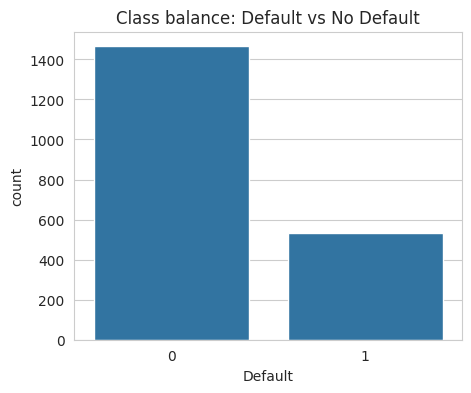

In [5]:
counts = df[TARGET_COLUMN].value_counts()
pct = df[TARGET_COLUMN].value_counts(normalize=True).round(3) * 100
print(pd.DataFrame({"count": counts, "pct": pct}))

plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title("Class balance: Default vs No Default")
plt.show()


The target is imbalanced — roughly a quarter of applicants default. This means **accuracy alone will be a misleading metric** later on: a model that always predicts "no default" would still score ~75% accuracy while being useless.

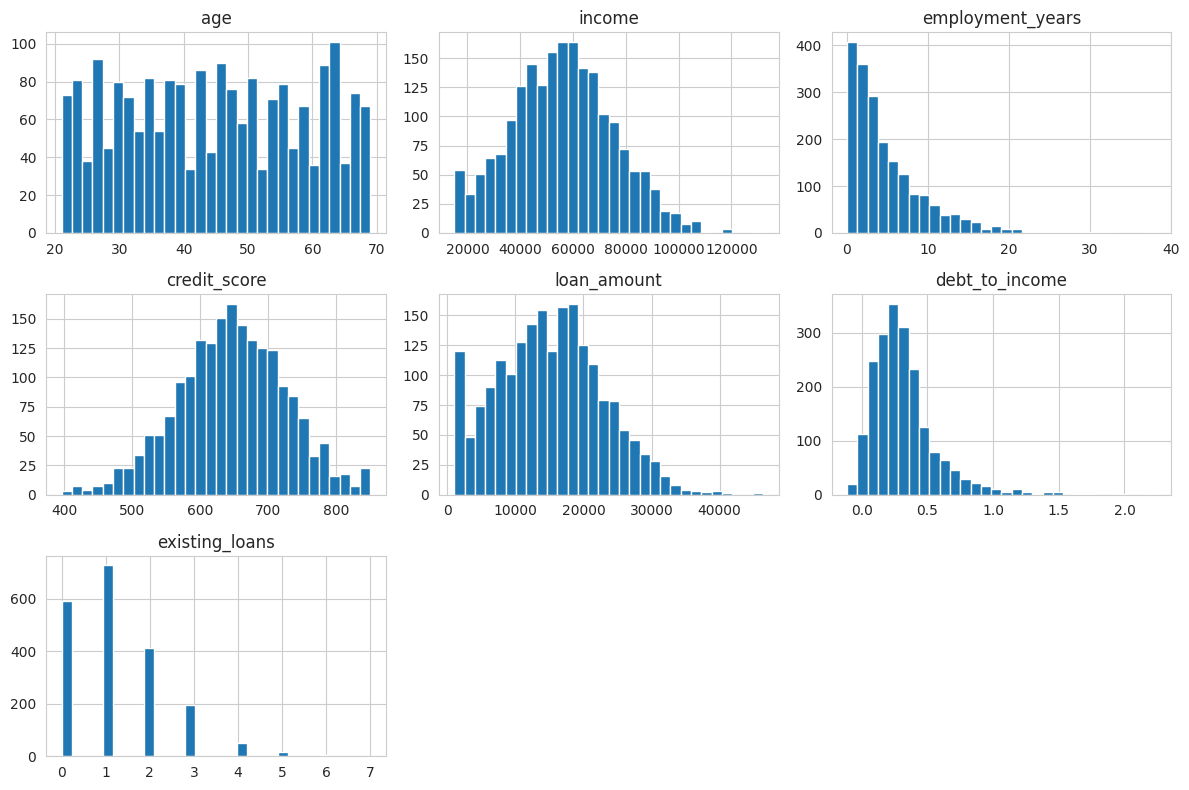

In [6]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove(TARGET_COLUMN)
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


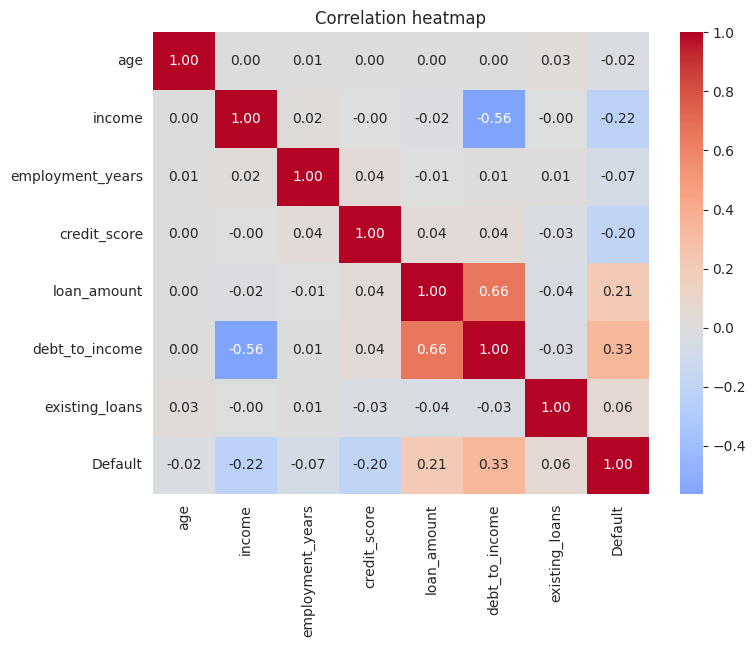

In [7]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + [TARGET_COLUMN]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


## 3. Data Cleaning and Feature Engineering

- Missing numeric values are filled with the median (robust to outliers).
- Missing categorical values are filled with the mode.
- We engineer `loan_to_income_ratio`, which often carries more signal than raw loan amount or income alone.
- Categorical columns are one-hot encoded so the models can use them.


In [8]:
df_clean = df.copy()
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean["loan_to_income_ratio"] = df_clean["loan_amount"] / df_clean["income"].replace(0, np.nan)
df_clean["loan_to_income_ratio"] = df_clean["loan_to_income_ratio"].fillna(0)

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"Shape after cleaning + encoding: {df_clean.shape}")
df_clean.head()


Shape after cleaning + encoding: (2000, 15)


/tmp/ipykernel_500/2839923685.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()


,age,income,employment_years,credit_score,loan_amount,debt_to_income,existing_loans,Default,loan_to_income_ratio,home_ownership_OWN,home_ownership_RENT,loan_purpose_debt_consolidation,loan_purpose_education,loan_purpose_home_improvement,loan_purpose_medical
0,58,64934.28,2.5,581.0,9598.57,0.131,0,0,0.147820,False,True,False,True,False,False
1,61,52234.71,1.3,648.0,13843.85,0.313,0,0,0.265032,False,False,False,False,False,False
2,27,67953.77,0.9,651.0,8660.64,0.160,1,0,0.127449,False,True,False,False,True,False
3,34,85460.60,5.5,688.0,12536.31,0.112,1,0,0.146691,False,False,False,False,False,True
4,63,50316.93,4.7,541.0,1000.00,-0.047,1,0,0.019874,False,True,False,True,False,False


## 4. Train/Test Split

We use a **stratified split** so the default rate stays consistent between train and test sets — important given the class imbalance.


In [9]:
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} rows, default rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]} rows, default rate {y_test.mean():.3f}")


Train: 1600 rows, default rate 0.268
Test:  400 rows, default rate 0.268


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Model Training

**Logistic Regression** — an interpretable baseline. `class_weight="balanced"` compensates for the imbalanced target by penalizing mistakes on the minority (default) class more heavily.

**Random Forest** — captures non-linear relationships between features, usually outperforms a linear baseline on tabular data like this.


In [11]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [12]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest trained.")


Random Forest trained.


## 6. Evaluation

Since the target is imbalanced, we look beyond accuracy: **precision, recall, F1, and ROC-AUC**. Recall on the "Default" class matters most in practice — missing an actual defaulter is usually costlier to a lender than a false alarm.



Logistic Regression
              precision    recall  f1-score   support

  No Default       0.86      0.71      0.78       293
     Default       0.46      0.67      0.55       107

    accuracy                           0.70       400
   macro avg       0.66      0.69      0.66       400
weighted avg       0.75      0.70      0.72       400

ROC-AUC: 0.736


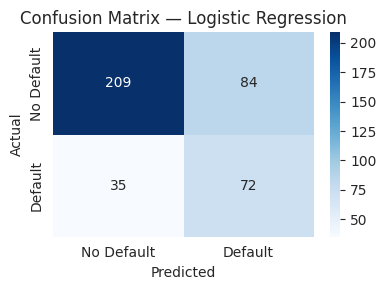

In [13]:
def evaluate(name, model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["No Default", "Default"]))
    auc = roc_auc_score(y_true, y_proba)
    print(f"ROC-AUC: {auc:.3f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()
    return y_proba, auc

proba_lr, auc_lr = evaluate("Logistic Regression", log_reg, X_test_scaled, y_test)



Random Forest


              precision    recall  f1-score   support

  No Default       0.79      0.91      0.84       293
     Default       0.57      0.33      0.42       107

    accuracy                           0.76       400
   macro avg       0.68      0.62      0.63       400
weighted avg       0.73      0.76      0.73       400

ROC-AUC: 0.703


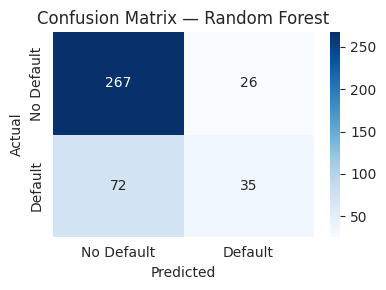

In [14]:
proba_rf, auc_rf = evaluate("Random Forest", rf, X_test, y_test)

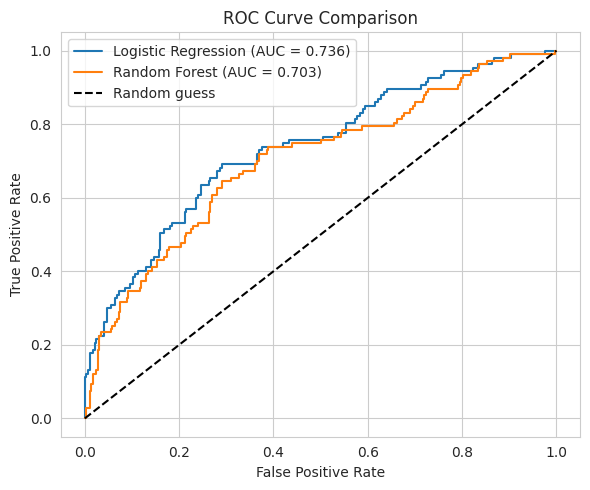

In [15]:
plt.figure(figsize=(6, 5))
for name, proba, auc in [("Logistic Regression", proba_lr, auc_lr), ("Random Forest", proba_rf, auc_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Feature Importance

Which factors drive the Random Forest's risk predictions the most?


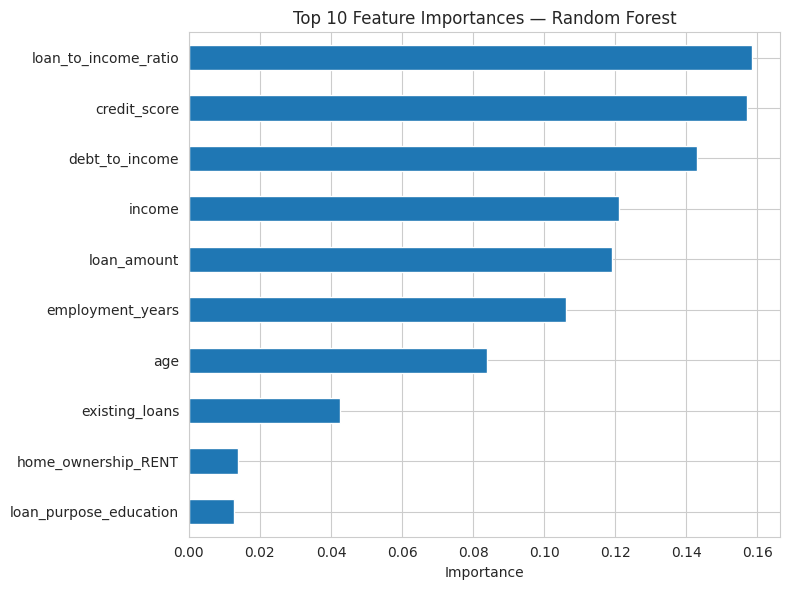

loan_to_income_ratio      0.158447
credit_score              0.157037
debt_to_income            0.142938
income                    0.121047
loan_amount               0.118979
employment_years          0.106216
age                       0.083916
existing_loans            0.042462
home_ownership_RENT       0.013717
loan_purpose_education    0.012610
dtype: float64

In [16]:
importances = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
importances.head(10)


## 8. Conclusion

Summarize for your capstone writeup:
- Which model had the better ROC-AUC?
- Which had better recall on the "Default" class (catching actual defaulters)?
- What were the top 3 risk drivers, and does that match real-world lending intuition (credit score, debt-to-income, etc.)?
- What would you improve with more time (more data, hyperparameter tuning, XGBoost, SHAP for interpretability)?
